# SA/2D Connection Authoring

Create, inspect, delete, and re-create SA/2D area connections in a real HEC-RAS
geometry file. This notebook demonstrates an engineering-oriented workflow for
the `Dam` connection in `BaldEagleDamBrk.g13`:

- inspect the connection line, crest profile, gates, terrain, mesh, and boundary context
- delete the `Dam` connection and prove the geometry no longer contains it
- re-create the `Dam` connection from the original alignment with deliberately different hydraulic parameters
- write a visibly different weir crest profile, including a raised spillway notch and lowered high shoulders
- move the gate opening stations and raise the gate invert elevation
- compute three scenarios: original connection, deleted/no-connection, and deleted-then-replaced connection
- compare total flow time series from the original and replaced connection, with the no-connection result shown as an absent structure

Primary APIs used:

- `GeomLateral.get_connections()` - list SA/2D connections
- `GeomLateral.get_connection_line_coords()` - read connection polyline coordinates
- `GeomLateral.get_connection_profile()` - read weir crest station/elevation profile
- `GeomLateral.get_connection_gates()` - read gate definitions
- `GeomLateral.delete_connection()` - remove a connection block
- `GeomLateral.set_connection()` - create or replace a connection block
- `GeomLateral.set_connection_profile()` - write the replacement weir crest profile
- `GeomLateral.set_connection_gates()` - write gate definitions
- `RasCmdr.compute_plan()` - compute each scenario through HEC-RAS
- `HdfStruc` and `HdfResultsBreach` - verify structure presence and extract total flow time series
- `HdfMesh` and `HdfBndry` - read mesh cells, mesh perimeters, and BC lines from the geometry HDF

The terrain profile in this notebook is sampled directly from the extracted
example project's `Terrain/Terrain50.dtm_20ft.tif` raster. `RasExamples.extract_project()`
provides that terrain raster, the `.rasmap`, and the compiled geometry HDF used
for the map context.


## Development Mode

In [1]:
#!pip install --upgrade ras-commander

In [2]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

from pathlib import Path
import os
import logging
import warnings

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import bounds as window_bounds
from rasterio.windows import from_bounds
from shapely.geometry import LineString, box

from IPython.display import display

from ras_commander import RasExamples
from ras_commander.geom import GeomLateral
from ras_commander.hdf import HdfBndry, HdfMesh

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def connection_line(coords_df):
    return LineString(coords_df[["X", "Y"]].to_numpy())


def expanded_bounds(bounds, fraction=0.25, min_pad=100.0):
    minx, miny, maxx, maxy = bounds
    width = max(maxx - minx, min_pad)
    height = max(maxy - miny, min_pad)
    pad_x = max(width * fraction, min_pad)
    pad_y = max(height * fraction, min_pad)
    return (minx - pad_x, miny - pad_y, maxx + pad_x, maxy + pad_y)


def sample_points_along_line(coords_df, spacing):
    line = connection_line(coords_df)
    stations = np.arange(0.0, line.length, spacing)
    if len(stations) == 0 or not np.isclose(stations[-1], line.length):
        stations = np.r_[stations, line.length]
    points = [line.interpolate(float(sta)) for sta in stations]
    return pd.DataFrame({
        "Station": np.round(stations, 3),
        "X": [pt.x for pt in points],
        "Y": [pt.y for pt in points],
    })
def interpolated_elevations(profile_df, stations):
    points = profile_df[["Station", "Elevation"]].astype(float).to_numpy()
    station_values = np.asarray(stations, dtype=float)
    elevations = []

    for station in station_values:
        exact = points[np.isclose(points[:, 0], station, atol=1e-6)]
        if len(exact):
            # Duplicate stations represent vertical weir faces. For an exact
            # vertical station, use the lower crest because it controls flow.
            elevations.append(float(exact[:, 1].min()))
            continue

        value = np.nan
        for (s0, e0), (s1, e1) in zip(points[:-1], points[1:]):
            if np.isclose(s0, s1):
                continue
            if s0 <= station <= s1:
                frac = (station - s0) / (s1 - s0)
                value = e0 + frac * (e1 - e0)
                break

        if np.isnan(value):
            value = points[0, 1] if station < points[0, 0] else points[-1, 1]
        elevations.append(float(value))

    return np.asarray(elevations)


def interpolate_profile_xy(coords_df, profile_df):
    line = connection_line(coords_df)
    profile = profile_df.copy()
    profile["Station"] = profile["Station"].astype(float).clip(0.0, line.length)
    points = [line.interpolate(float(sta)) for sta in profile["Station"]]
    profile["X"] = [pt.x for pt in points]
    profile["Y"] = [pt.y for pt in points]
    return profile


def profile_difference(original_profile, modified_profile):
    stations = np.array(sorted(
        set(np.round(original_profile["Station"].astype(float), 3)).union(
            set(np.round(modified_profile["Station"].astype(float), 3))
        )
    ))
    original = interpolated_elevations(original_profile, stations)
    modified = interpolated_elevations(modified_profile, stations)
    return pd.DataFrame({
        "Station": stations,
        "OriginalElevation": original,
        "ModifiedElevation": modified,
        "Delta": modified - original,
        "AbsDelta": np.abs(modified - original),
    })


def sample_terrain_profile(coords_df, terrain_raster, spacing):
    samples = sample_points_along_line(coords_df, spacing)
    xy = list(zip(samples["X"], samples["Y"]))
    elevations = []
    with rasterio.open(terrain_raster) as src:
        for value in src.sample(xy, masked=True):
            elev = value[0]
            elevations.append(np.nan if np.ma.is_masked(elev) else float(elev))

    samples["Elevation"] = elevations
    if samples["Elevation"].isna().any():
        samples["Elevation"] = samples["Elevation"].interpolate(limit_direction="both")
    if samples["Elevation"].isna().any():
        raise ValueError("Terrain sampling produced unresolved NoData elevations.")
    return samples[["Station", "Elevation", "X", "Y"]]


def hillshade(elev_ma, azimuth=315, altitude=45):
    arr = np.ma.filled(elev_ma.astype(float), np.nan)
    if np.isnan(arr).all():
        return np.ma.masked_all(arr.shape)
    arr = np.where(np.isnan(arr), np.nanmean(arr), arr)
    dy, dx = np.gradient(arr)
    slope = np.pi / 2.0 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    az = np.deg2rad(azimuth)
    alt = np.deg2rad(altitude)
    shaded = (
        np.sin(alt) * np.sin(slope)
        + np.cos(alt) * np.cos(slope) * np.cos(az - aspect)
    )
    return np.clip((shaded + 1.0) / 2.0, 0.0, 1.0)


def read_terrain_window(terrain_raster, bounds, max_pixels=900):
    left, bottom, right, top = bounds
    with rasterio.open(terrain_raster) as src:
        window = from_bounds(left, bottom, right, top, transform=src.transform)
        window = window.round_offsets().round_lengths()
        scale = max(window.width / max_pixels, window.height / max_pixels, 1.0)
        out_height = max(1, int(window.height / scale))
        out_width = max(1, int(window.width / scale))
        elev = src.read(
            1,
            window=window,
            out_shape=(out_height, out_width),
            masked=True,
            boundless=True,
            resampling=Resampling.bilinear,
        )
        left, bottom, right, top = window_bounds(window, src.transform)
        extent = (left, right, bottom, top)
    return elev, extent


def add_north_arrow(ax):
    ax.annotate(
        "N",
        xy=(0.94, 0.90),
        xytext=(0.94, 0.78),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=10,
        arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1.5),
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="0.7", alpha=0.8),
        zorder=20,
    )


def nice_scale_length(raw_length):
    if raw_length <= 0:
        return 100.0
    exponent = np.floor(np.log10(raw_length))
    base = raw_length / (10 ** exponent)
    step = 1 if base < 1.5 else 2 if base < 3.5 else 5 if base < 7.5 else 10
    return float(step * (10 ** exponent))


def add_scale_bar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    width = xmax - xmin
    height = ymax - ymin
    length = nice_scale_length(width * 0.18)
    x0 = xmin + width * 0.06
    y0 = ymin + height * 0.07
    ax.plot([x0, x0 + length], [y0, y0], color="black", linewidth=3, zorder=20)
    ax.plot([x0, x0], [y0 - height * 0.01, y0 + height * 0.01], color="black", linewidth=1.5, zorder=20)
    ax.plot([x0 + length, x0 + length], [y0 - height * 0.01, y0 + height * 0.01], color="black", linewidth=1.5, zorder=20)
    label = f"{length:,.0f} ft" if length < 5280 else f"{length / 5280:.1f} mi"
    ax.text(
        x0 + length / 2,
        y0 + height * 0.025,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.8, pad=2),
        zorder=20,
    )


def dedupe_legend(ax, loc="upper right", fontsize=8):
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for handle, label in zip(handles, labels):
        if label and label not in seen:
            seen[label] = handle
    if seen:
        ax.legend(seen.values(), seen.keys(), loc=loc, fontsize=fontsize, frameon=True)


def label_lines(ax, gdf, column, bounds, fontsize=8):
    if gdf.empty:
        return
    view = box(*bounds)
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty or not geom.intersects(view):
            continue
        label_pt = geom.interpolate(0.5, normalized=True)
        ax.text(
            label_pt.x,
            label_pt.y,
            str(row[column]),
            fontsize=fontsize,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.75, pad=1.5),
            zorder=15,
        )


def plot_context_map(
    ax,
    terrain_raster,
    mesh_areas,
    mesh_cells,
    bc_lines,
    bounds,
    title,
    show_cells=True,
):
    elev, extent = read_terrain_window(terrain_raster, bounds)
    valid = elev.compressed()
    if len(valid):
        vmin, vmax = np.percentile(valid, [2, 98])
    else:
        vmin, vmax = None, None
    ax.imshow(
        elev,
        extent=extent,
        origin="upper",
        cmap="gist_earth",
        vmin=vmin,
        vmax=vmax,
        alpha=0.82,
        zorder=0,
    )
    ax.imshow(hillshade(elev), extent=extent, origin="upper", cmap="gray", alpha=0.22, zorder=1)
    if len(valid):
        left_e, right_e, bottom_e, top_e = extent
        xs = np.linspace(left_e, right_e, elev.shape[1])
        ys = np.linspace(top_e, bottom_e, elev.shape[0])
        levels = np.linspace(vmin, vmax, 9)
        ax.contour(
            xs,
            ys,
            np.ma.filled(elev, np.nan),
            levels=levels,
            colors="white",
            linewidths=0.3,
            alpha=0.45,
            zorder=2,
        )

    left, bottom, right, top = bounds
    if show_cells and not mesh_cells.empty:
        cells_view = mesh_cells.cx[left:right, bottom:top]
        if not cells_view.empty:
            cells_view.boundary.plot(ax=ax, color="#4a5568", linewidth=0.28, alpha=0.50, zorder=3, label="2D mesh cells")

    if not mesh_areas.empty:
        mesh_areas.boundary.plot(ax=ax, color="#1f4e79", linewidth=1.2, alpha=0.95, zorder=4, label="2D flow area")
        for _, row in mesh_areas.iterrows():
            pt = row.geometry.representative_point()
            if left <= pt.x <= right and bottom <= pt.y <= top:
                ax.text(
                    pt.x,
                    pt.y,
                    row["mesh_name"],
                    fontsize=9,
                    weight="bold",
                    ha="center",
                    va="center",
                    bbox=dict(facecolor="white", edgecolor="#1f4e79", alpha=0.7, pad=2),
                    zorder=14,
                )

    if not bc_lines.empty:
        bc_view = bc_lines.cx[left:right, bottom:top]
        if not bc_view.empty:
            bc_view.plot(ax=ax, color="#2b6cb0", linewidth=2.0, linestyle="--", zorder=6, label="BC line")
            label_lines(ax, bc_view, "Name", bounds)

    ax.set_xlim(left, right)
    ax.set_ylim(bottom, top)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("Easting (ft)")
    ax.set_ylabel("Northing (ft)")
    add_north_arrow(ax)
    add_scale_bar(ax)


def add_gate_rectangles(ax, gates, facecolor="#e17c05", edgecolor="#9a3412", label="Gate opening"):
    label_used = False
    if gates.empty:
        return
    for _, gate in gates.iterrows():
        stations = gate.get("OpeningStations", []) or []
        width = float(gate.get("Width", 0.0) or 0.0)
        height = float(gate.get("Height", 0.0) or 0.0)
        invert = float(gate.get("InvertElevation", np.nan))
        if width <= 0 or height <= 0 or np.isnan(invert):
            continue
        for sta in stations:
            rect = Rectangle(
                (float(sta) - width / 2.0, invert),
                width,
                height,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=1.1,
                alpha=0.28,
                label=label if not label_used else None,
                zorder=8,
            )
            ax.add_patch(rect)
            ax.text(
                float(sta),
                invert + height,
                gate["GateName"],
                fontsize=7,
                ha="center",
                va="bottom",
                color=edgecolor,
                rotation=90,
                zorder=9,
            )
            label_used = True


def set_profile_ylim(ax, profiles, gates=None):
    if gates is None:
        gates = pd.DataFrame()
    values = []
    for profile in profiles:
        values.extend(profile["Elevation"].dropna().tolist())
    if not gates.empty:
        for _, gate in gates.iterrows():
            invert = float(gate.get("InvertElevation", np.nan))
            height = float(gate.get("Height", 0.0) or 0.0)
            if not np.isnan(invert):
                values.extend([invert, invert + height])
    if values:
        ymin, ymax = min(values), max(values)
        pad = max((ymax - ymin) * 0.08, 2.0)
        ax.set_ylim(ymin - pad, ymax + pad)


def add_gate_station_markers(ax, gates):
    if gates.empty:
        return
    top = ax.get_ylim()[1]
    for _, gate in gates.iterrows():
        stations = gate.get("OpeningStations", []) or []
        for sta in stations:
            ax.axvline(float(sta), color="#9a3412", linewidth=0.9, alpha=0.45, zorder=3)
            ax.text(
                float(sta),
                top,
                gate["GateName"],
                fontsize=7,
                ha="center",
                va="top",
                color="#9a3412",
                rotation=90,
                zorder=9,
            )


def plot_gate_band(ax, gates):
    if gates.empty:
        ax.text(0.5, 0.5, "No gates", transform=ax.transAxes, ha="center", va="center")
        return
    add_gate_rectangles(ax, gates)
    values = []
    for _, gate in gates.iterrows():
        invert = float(gate.get("InvertElevation", np.nan))
        height = float(gate.get("Height", 0.0) or 0.0)
        if not np.isnan(invert):
            values.extend([invert, invert + height])
    ymin, ymax = min(values), max(values)
    pad = max((ymax - ymin) * 0.25, 2.0)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_ylabel("Gate elev. (ft)")
    ax.set_xlabel("Station along connection (ft)")
    ax.set_title("Gate Opening Elevations")
    dedupe_legend(ax, loc="upper right", fontsize=7)


def plot_profile(ax, terrain_profile, crest_profile, gates, title, crest_label, show_gate_rectangles=True):
    ax.plot(
        terrain_profile["Station"],
        terrain_profile["Elevation"],
        color="0.55",
        linewidth=1.4,
        linestyle="--",
        label="Terrain profile",
        zorder=2,
    )
    ax.plot(
        crest_profile["Station"],
        crest_profile["Elevation"],
        color="#1f4e79",
        linewidth=2.1,
        label=crest_label,
        zorder=4,
    )
    if show_gate_rectangles:
        add_gate_rectangles(ax, gates)
    ax.set_title(title)
    ax.set_xlabel("Station along connection (ft)")
    ax.set_ylabel("Elevation (ft)")
    set_profile_ylim(ax, [terrain_profile, crest_profile], gates if show_gate_rectangles else None)
    dedupe_legend(ax, loc="lower right")


def save_figure(fig, filename):
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=180)
    print(f"Saved figure: {output_path}")


import ras_commander

print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE: loading installed ras-commander


Loaded: G:\GH\ras-commander\ras_commander\__init__.py


## Parameters

In [3]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
PROJECT_SUFFIX = "214_connection_authoring"
GEOM_FILE_NAME = "BaldEagleDamBrk.g13"
TARGET_CONNECTION = "Dam"
SCENARIO_PLAN_NUMBER = "04"

TERRAIN_RASTER_NAME = "Terrain50.dtm_20ft.tif"
TERRAIN_SAMPLE_SPACING_FT = 25.0

REPLACEMENT_WEIR_WIDTH_FT = 180.0
REPLACEMENT_WEIR_COEF = 2.25
REPLACEMENT_PROFILE_STATIONS_FT = [0.0, 1800.0, 2250.0, 3050.0, 3350.0, 5400.0, 7423.0]
REPLACEMENT_PROFILE_ELEVATIONS_FT = [678.0, 678.0, 661.0, 661.0, 678.0, 678.0, 678.0]
REPLACEMENT_GATE_STATIONS_FT = [5480.0, 5960.0]
REPLACEMENT_GATE_INVERT_FT = 600.0
REPLACEMENT_GATE_HEIGHT_FT = 16.0
REPLACEMENT_GATE_WIDTH_FT = 12.0
REPLACEMENT_GATE_COEF = 0.72

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "ras_commander").exists() else cwd.parent
WORK_ROOT = REPO_ROOT / "working" / "connection_authoring"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = Path(
    os.environ.get(
        "RAS_COMMANDER_NOTEBOOK_FIGURE_DIR",
        str(WORK_ROOT / "figures"),
    )
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working folder: {WORK_ROOT}")
print(f"Figure folder: {FIGURE_DIR}")


Working folder: G:\GH\ras-commander\working\connection_authoring
Figure folder: G:\GH\ras-commander\working\connection_authoring\figures


## Extract And Inspect The Project

In [4]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix=PROJECT_SUFFIX,
)
geom_file = project_path / GEOM_FILE_NAME
geom_hdf = project_path / f"{GEOM_FILE_NAME}.hdf"
rasmap_file = project_path / "BaldEagleDamBrk.rasmap"
terrain_raster = project_path / "Terrain" / TERRAIN_RASTER_NAME

print(f"Project path: {project_path}")
print(f"Geometry file: {geom_file.name}")
print(f"Geometry HDF: {geom_hdf.name}")
print(f"RASMapper file: {rasmap_file.name}")
print(f"Terrain raster: {terrain_raster.relative_to(project_path)}")

assert geom_file.exists()
assert geom_hdf.exists()
assert rasmap_file.exists()
assert terrain_raster.exists()

connections = GeomLateral.get_connections(geom_file)
display_cols = ["Name", "Type", "From", "To", "NumPoints", "LinePoints", "HasGate"]
display(connections[display_cols])

mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
mesh_cells = HdfMesh.get_mesh_cell_polygons(geom_hdf)
bc_lines = HdfBndry.get_bc_lines(geom_hdf)

connection_lines = {}
for name in connections["Name"]:
    try:
        connection_lines[name] = GeomLateral.get_connection_line_coords(geom_file, name)
    except ValueError:
        pass

context_summary = pd.DataFrame([{
    "Connections": len(connections),
    "2D Flow Areas": len(mesh_areas),
    "2D Mesh Cells": len(mesh_cells),
    "BC Lines": len(bc_lines),
    "Terrain Source": str(terrain_raster.relative_to(project_path)),
    "Mesh Source": geom_hdf.name,
}])
display(context_summary)

Project path: G:\GH\ras-commander\working\connection_authoring\BaldEagleCrkMulti2D_214_connection_authoring
Geometry file: BaldEagleDamBrk.g13
Geometry HDF: BaldEagleDamBrk.g13.hdf
RASMapper file: BaldEagleDamBrk.rasmap
Terrain raster: Terrain\Terrain50.dtm_20ft.tif


,Name,Type,From,To,NumPoints,LinePoints,HasGate
0,Dam,SA to 2D,Reservoir Pool,BaldEagleCr,6,18,True
1,Lower Levee,2D to 2D,BaldEagleCr,BaldEagleCr,94,89,False
2,Middle Levee,2D to 2D,BaldEagleCr,BaldEagleCr,130,122,False
3,Upper Levee,2D to 2D,BaldEagleCr,BaldEagleCr,101,99,False


,Connections,2D Flow Areas,2D Mesh Cells,BC Lines,Terrain Source,Mesh Source
0,4,1,14364,2,Terrain\Terrain50.dtm_20ft.tif,BaldEagleDamBrk.g13.hdf


## Model Context And Visualization Targets

Before modifying the connection, an engineer needs enough spatial and hydraulic
context to interpret the profile:

- target connection alignment and adjacent storage/2D flow areas
- 2D mesh perimeter and local cells crossed by the connection
- downstream boundary condition locations
- underlying terrain along and around the connection
- weir crest station/elevation profile and gate openings

The overview below locates the target connection in the model. The detailed
inspection maps that follow zoom to the connection line with a 25 percent margin
around its extents.

Saved figure: G:\GH\ras-commander\working\connection_authoring\figures\214_connection_authoring_model_overview.png


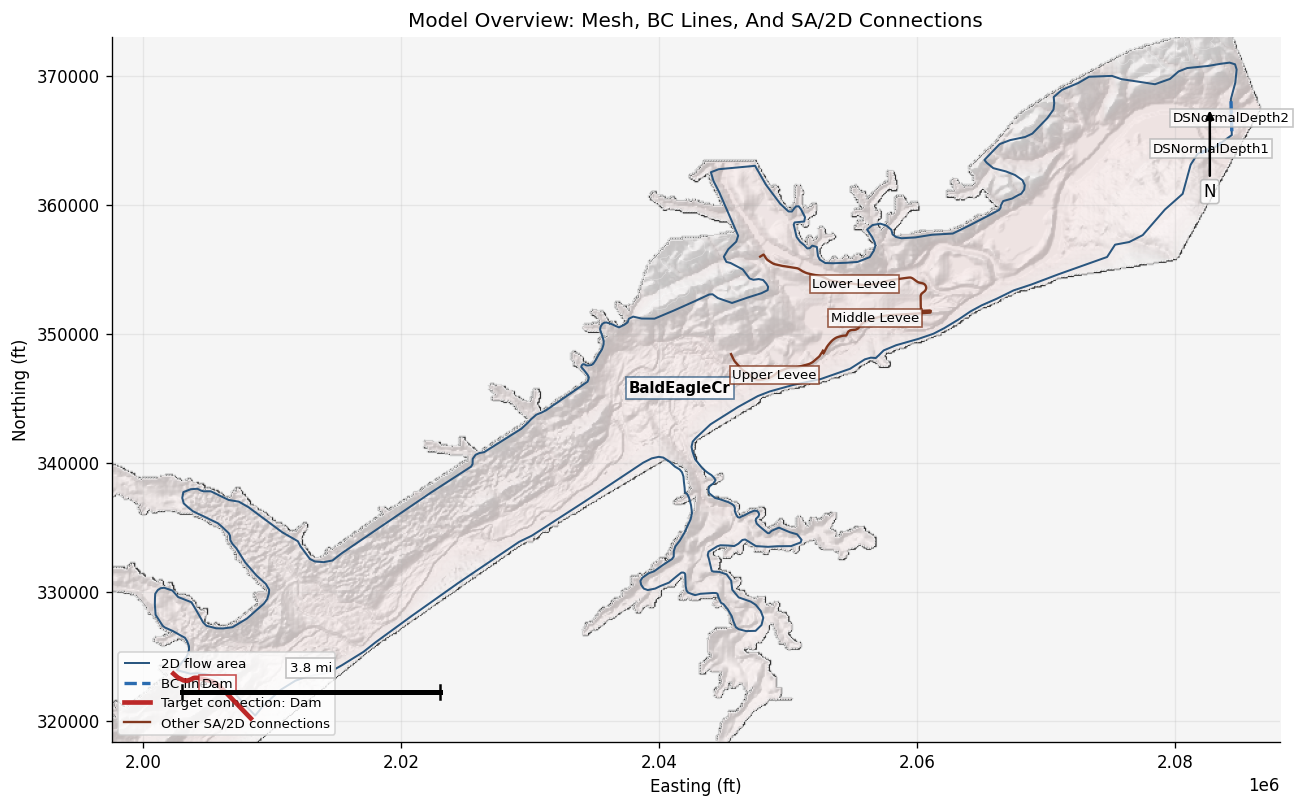

In [5]:
target_coords = connection_lines[TARGET_CONNECTION]
target_line = connection_line(target_coords)
overview_bounds = expanded_bounds(mesh_areas.total_bounds, fraction=0.04, min_pad=1000.0)

fig, ax = plt.subplots(figsize=(11, 7))
plot_context_map(
    ax,
    terrain_raster,
    mesh_areas,
    mesh_cells,
    bc_lines,
    overview_bounds,
    "Model Overview: Mesh, BC Lines, And SA/2D Connections",
    show_cells=False,
)

for name, coords in connection_lines.items():
    color = "#b91c1c" if name == TARGET_CONNECTION else "#7c2d12"
    linewidth = 2.8 if name == TARGET_CONNECTION else 1.4
    label = f"Target connection: {name}" if name == TARGET_CONNECTION else "Other SA/2D connections"
    ax.plot(coords["X"], coords["Y"], color=color, linewidth=linewidth, alpha=0.95, zorder=8, label=label)
    mid = connection_line(coords).interpolate(0.5, normalized=True)
    ax.text(
        mid.x,
        mid.y,
        name,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", edgecolor=color, alpha=0.75, pad=1.5),
        zorder=16,
    )

dedupe_legend(ax, loc="lower left")
fig.tight_layout()
save_figure(fig, "214_connection_authoring_model_overview.png")
plt.show()

## Inspect The Target Connection

In [6]:
original_coords = GeomLateral.get_connection_line_coords(geom_file, TARGET_CONNECTION)
original_profile = GeomLateral.get_connection_profile(geom_file, TARGET_CONNECTION)
original_gates = GeomLateral.get_connection_gates(geom_file, TARGET_CONNECTION)
terrain_profile = sample_terrain_profile(
    original_coords,
    terrain_raster,
    TERRAIN_SAMPLE_SPACING_FT,
)

print(f"Connection line points: {len(original_coords)}")
print(f"Original weir crest points: {len(original_profile)}")
print(f"Terrain profile samples: {len(terrain_profile)} at {TERRAIN_SAMPLE_SPACING_FT:g} ft spacing")
print(f"Gates: {len(original_gates)}")

gate_cols = ["GateName", "Width", "Height", "InvertElevation", "GateCoefficient", "NumOpenings", "OpeningStations"]
profile_stats = pd.DataFrame([{
    "Source": "Existing weir crest",
    "Points": len(original_profile),
    "Min Elev": original_profile["Elevation"].min(),
    "Max Elev": original_profile["Elevation"].max(),
    "Min Station": original_profile.loc[original_profile["Elevation"].idxmin(), "Station"],
}, {
    "Source": "Terrain raster sample",
    "Points": len(terrain_profile),
    "Min Elev": terrain_profile["Elevation"].min(),
    "Max Elev": terrain_profile["Elevation"].max(),
    "Min Station": terrain_profile.loc[terrain_profile["Elevation"].idxmin(), "Station"],
}])
display(profile_stats.round(3))
display(original_gates[gate_cols])

Connection line points: 18
Original weir crest points: 6
Terrain profile samples: 298 at 25 ft spacing
Gates: 1


,Source,Points,Min Elev,Max Elev,Min Station
0,Existing weir crest,6,657.000,683.0,2250.0
1,Terrain raster sample,298,647.656,692.5,2275.0


,GateName,Width,Height,InvertElevation,GateCoefficient,NumOpenings,OpeningStations
0,Gate #1,7.0,15.0,590.0,0.65,2,"[5745.0, 5765.0]"


## Weir Crest Profile With Terrain And Gates

Saved figure: G:\GH\ras-commander\working\connection_authoring\figures\214_connection_authoring_existing_profile.png

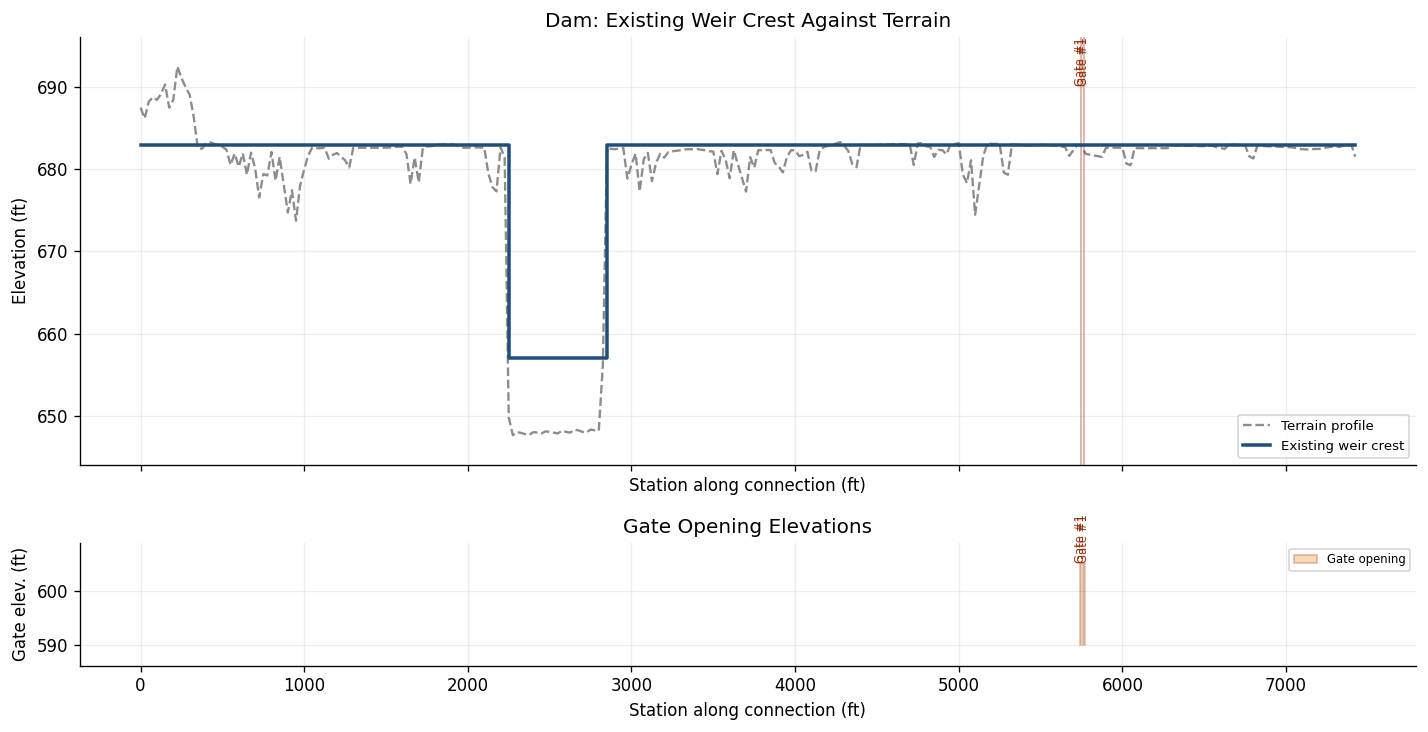

In [7]:
fig, (ax, gate_ax) = plt.subplots(
    2,
    1,
    figsize=(12, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [4.0, 1.15]},
)
plot_profile(
    ax,
    terrain_profile,
    original_profile,
    original_gates,
    f"{TARGET_CONNECTION}: Existing Weir Crest Against Terrain",
    "Existing weir crest",
    show_gate_rectangles=False,
)
add_gate_station_markers(ax, original_gates)
plot_gate_band(gate_ax, original_gates)
fig.tight_layout()
save_figure(fig, "214_connection_authoring_existing_profile.png")
plt.show()

## Connection Map View

Saved figure: G:\GH\ras-commander\working\connection_authoring\figures\214_connection_authoring_connection_map.png


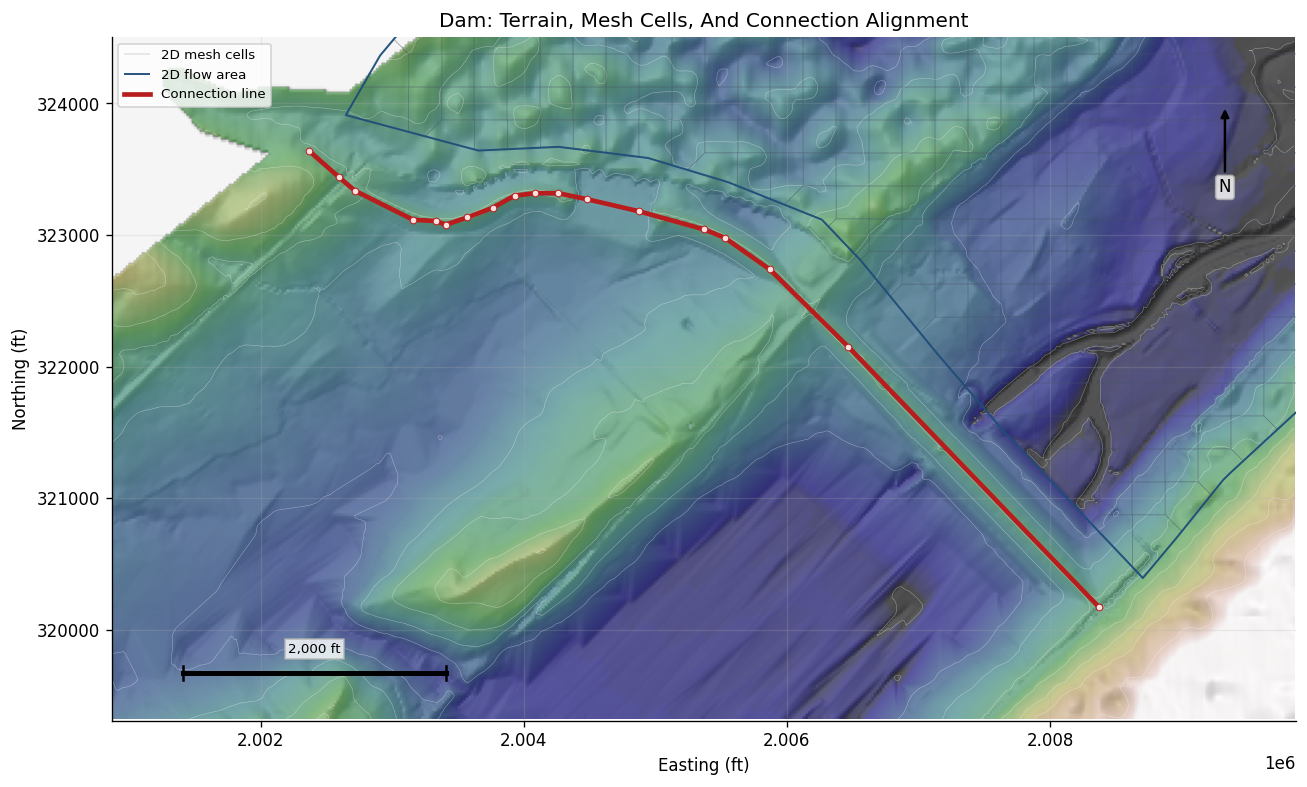

In [8]:
connection_bounds = expanded_bounds(target_line.bounds, fraction=0.25, min_pad=250.0)

fig, ax = plt.subplots(figsize=(11, 7))
plot_context_map(
    ax,
    terrain_raster,
    mesh_areas,
    mesh_cells,
    bc_lines,
    connection_bounds,
    f"{TARGET_CONNECTION}: Terrain, Mesh Cells, And Connection Alignment",
    show_cells=True,
)
ax.plot(original_coords["X"], original_coords["Y"], color="#b91c1c", linewidth=2.8, zorder=10, label="Connection line")
ax.scatter(original_coords["X"], original_coords["Y"], s=16, color="#fee2e2", edgecolor="#b91c1c", linewidth=0.6, zorder=11)

dedupe_legend(ax, loc="upper left")
fig.tight_layout()
save_figure(fig, "214_connection_authoring_connection_map.png")
plt.show()

## Delete The Connection

In [9]:
before_delete = GeomLateral.get_connections(geom_file)
GeomLateral.delete_connection(geom_file, TARGET_CONNECTION, create_backup=True)

after_delete = GeomLateral.get_connections(geom_file)
delete_proof = pd.DataFrame([
    {
        "Step": "Before delete",
        "Connection Count": len(before_delete),
        "Dam Present": TARGET_CONNECTION in before_delete["Name"].values,
    },
    {
        "Step": "After delete",
        "Connection Count": len(after_delete),
        "Dam Present": TARGET_CONNECTION in after_delete["Name"].values,
    },
])
display(delete_proof)
display(after_delete[["Name", "Type", "From", "To"]])

assert TARGET_CONNECTION not in after_delete["Name"].values
assert len(after_delete) == len(connections) - 1
print(f"Verified deletion: '{TARGET_CONNECTION}' is absent and {len(after_delete)} connections remain.")


,Step,Connection Count,Dam Present
0,Before delete,4,True
1,After delete,3,False


,Name,Type,From,To
0,Lower Levee,2D to 2D,BaldEagleCr,BaldEagleCr
1,Middle Levee,2D to 2D,BaldEagleCr,BaldEagleCr
2,Upper Levee,2D to 2D,BaldEagleCr,BaldEagleCr


Verified deletion: 'Dam' is absent and 3 connections remain.


## Re-Create The Connection With Modified Parameters

In [10]:
coords_tuples = list(zip(
    original_coords["X"].tolist(),
    original_coords["Y"].tolist(),
))

dam_row = connections.loc[connections["Name"] == TARGET_CONNECTION].iloc[0]

GeomLateral.set_connection(
    geom_file,
    TARGET_CONNECTION,
    coords_tuples,
    upstream_area=dam_row["From"],
    downstream_area=dam_row["To"],
    routing_type=1,
    weir_width=REPLACEMENT_WEIR_WIDTH_FT,
    weir_coef=REPLACEMENT_WEIR_COEF,
    overflow_method_2d=True,
    create_backup=False,
)

after_recreate = GeomLateral.get_connections(geom_file)
recreate_proof = pd.DataFrame([
    {
        "Step": "After delete",
        "Connection Count": len(after_delete),
        "Dam Present": TARGET_CONNECTION in after_delete["Name"].values,
        "Weir Width": np.nan,
        "Weir Coef": np.nan,
    },
    {
        "Step": "After recreate",
        "Connection Count": len(after_recreate),
        "Dam Present": TARGET_CONNECTION in after_recreate["Name"].values,
        "Weir Width": REPLACEMENT_WEIR_WIDTH_FT,
        "Weir Coef": REPLACEMENT_WEIR_COEF,
    },
])
display(recreate_proof)
display(after_recreate[["Name", "Type", "From", "To", "NumPoints", "LinePoints"]])

assert TARGET_CONNECTION in after_recreate["Name"].values
assert len(after_recreate) == len(connections)
print(
    f"Re-created '{TARGET_CONNECTION}' after deletion with "
    f"weir width {REPLACEMENT_WEIR_WIDTH_FT:g} ft and coefficient {REPLACEMENT_WEIR_COEF:g}."
)


,Step,Connection Count,Dam Present,Weir Width,Weir Coef
0,After delete,3,False,NaN,NaN
1,After recreate,4,True,180.0,2.25


,Name,Type,From,To,NumPoints,LinePoints
0,Lower Levee,2D to 2D,BaldEagleCr,BaldEagleCr,94,89
1,Middle Levee,2D to 2D,BaldEagleCr,BaldEagleCr,130,122
2,Upper Levee,2D to 2D,BaldEagleCr,BaldEagleCr,101,99
3,Dam,SA to 2D,Reservoir Pool,BaldEagleCr,2,18


Re-created 'Dam' after deletion with weir width 180 ft and coefficient 2.25.


## Write A Deliberately Modified Weir Crest


In [11]:
replacement_profile = pd.DataFrame({
    "Station": REPLACEMENT_PROFILE_STATIONS_FT,
    "Elevation": REPLACEMENT_PROFILE_ELEVATIONS_FT,
})
modified_profile = interpolate_profile_xy(original_coords, replacement_profile)

GeomLateral.set_connection_profile(
    geom_file,
    TARGET_CONNECTION,
    replacement_profile,
    create_backup=False,
)

updated_profile = GeomLateral.get_connection_profile(geom_file, TARGET_CONNECTION)
updated_profile_xy = interpolate_profile_xy(original_coords, updated_profile)
profile_comparison = profile_difference(original_profile, updated_profile)

profile_change_summary = pd.DataFrame([{
    "Original Points": len(original_profile),
    "Replacement Points": len(updated_profile),
    "Original Min Elev": original_profile["Elevation"].min(),
    "Replacement Min Elev": updated_profile["Elevation"].min(),
    "Max Crest Raise": profile_comparison["Delta"].max(),
    "Max Crest Lowering": profile_comparison["Delta"].min(),
    "Largest Absolute Change": profile_comparison["AbsDelta"].max(),
}])
display(profile_change_summary.round(3))
display(
    profile_comparison
    .sort_values("AbsDelta", ascending=False)
    .head(8)
    .round(3)
)

assert len(updated_profile) == len(replacement_profile)
assert np.allclose(updated_profile["Station"], replacement_profile["Station"], atol=0.001)
assert np.allclose(updated_profile["Elevation"], replacement_profile["Elevation"], atol=0.001)
assert profile_comparison["AbsDelta"].max() >= 5.0
print(
    f"Wrote replacement crest profile: {len(updated_profile)} points, "
    f"min elevation {updated_profile['Elevation'].min():.1f} ft, "
    f"largest absolute change {profile_comparison['AbsDelta'].max():.1f} ft."
)


,Original Points,Replacement Points,Original Min Elev,Replacement Min Elev,Max Crest Raise,Max Crest Lowering,Largest Absolute Change
0,6,7,657.0,661.0,4.0,-22.0,22.0


,Station,OriginalElevation,ModifiedElevation,Delta,AbsDelta
4,3050.0,683.0,661.0,-22.0,22.0
0,0.0,683.0,678.0,-5.0,5.0
5,3350.0,683.0,678.0,-5.0,5.0
1,1800.0,683.0,678.0,-5.0,5.0
6,5400.0,683.0,678.0,-5.0,5.0
7,7423.0,683.0,678.0,-5.0,5.0
3,2850.0,657.0,661.0,4.0,4.0
2,2250.0,657.0,661.0,4.0,4.0


Wrote replacement crest profile: 7 points, min elevation 661.0 ft, largest absolute change 22.0 ft.


## Add Modified Gates

In [12]:
new_gates = [
    {
        "GateName": "Gate #1",
        "Width": REPLACEMENT_GATE_WIDTH_FT,
        "Height": REPLACEMENT_GATE_HEIGHT_FT,
        "InvertElevation": REPLACEMENT_GATE_INVERT_FT,
        "GateCoefficient": REPLACEMENT_GATE_COEF,
        "NumOpenings": len(REPLACEMENT_GATE_STATIONS_FT),
        "OpeningStations": REPLACEMENT_GATE_STATIONS_FT,
    },
]

GeomLateral.set_connection_gates(
    geom_file,
    TARGET_CONNECTION,
    new_gates,
    create_backup=False,
)

restored_gates = GeomLateral.get_connection_gates(geom_file, TARGET_CONNECTION)

gate_change_summary = pd.DataFrame([
    {
        "Version": "Original",
        "GateName": original_gates.iloc[0]["GateName"],
        "Width": original_gates.iloc[0]["Width"],
        "Height": original_gates.iloc[0]["Height"],
        "InvertElevation": original_gates.iloc[0]["InvertElevation"],
        "TopElevation": original_gates.iloc[0]["InvertElevation"] + original_gates.iloc[0]["Height"],
        "OpeningStations": original_gates.iloc[0]["OpeningStations"],
    },
    {
        "Version": "Replacement",
        "GateName": restored_gates.iloc[0]["GateName"],
        "Width": restored_gates.iloc[0]["Width"],
        "Height": restored_gates.iloc[0]["Height"],
        "InvertElevation": restored_gates.iloc[0]["InvertElevation"],
        "TopElevation": restored_gates.iloc[0]["InvertElevation"] + restored_gates.iloc[0]["Height"],
        "OpeningStations": restored_gates.iloc[0]["OpeningStations"],
    },
])
display(gate_change_summary)
display(restored_gates[gate_cols])

assert len(restored_gates) == len(new_gates)
for i, expected in enumerate(new_gates):
    actual = restored_gates.iloc[i]
    assert actual["GateName"] == expected["GateName"], f"Gate {i} name mismatch"
    assert actual["Width"] == expected["Width"], f"Gate {i} width mismatch"
    assert actual["Height"] == expected["Height"], f"Gate {i} height mismatch"
    assert np.isclose(actual["InvertElevation"], expected["InvertElevation"], atol=0.01), (
        f"Gate {i} invert mismatch: expected {expected['InvertElevation']}, got {actual['InvertElevation']}"
    )
    assert np.isclose(actual["GateCoefficient"], expected["GateCoefficient"], atol=0.01), (
        f"Gate {i} coefficient mismatch: expected {expected['GateCoefficient']}, got {actual['GateCoefficient']}"
    )
    assert actual["NumOpenings"] == expected["NumOpenings"], f"Gate {i} num openings mismatch"
    actual_stations = [float(s) for s in actual["OpeningStations"]]
    expected_stations = [float(s) for s in expected["OpeningStations"]]
    assert actual_stations == expected_stations, (
        f"Gate {i} stations mismatch: expected {expected_stations}, got {actual_stations}"
    )

assert restored_gates.iloc[0]["OpeningStations"] != original_gates.iloc[0]["OpeningStations"]
assert restored_gates.iloc[0]["InvertElevation"] != original_gates.iloc[0]["InvertElevation"]
print(
    f"Wrote replacement gate: stations {restored_gates.iloc[0]['OpeningStations']}, "
    f"invert {restored_gates.iloc[0]['InvertElevation']:.1f} ft."
)


,Version,GateName,Width,Height,InvertElevation,TopElevation,OpeningStations
0,Original,Gate #1,7.0,15.0,590.0,605.0,"[5745.0, 5765.0]"
1,Replacement,Gate #1,12.0,16.0,600.0,616.0,"[5480.0, 5960.0]"


,GateName,Width,Height,InvertElevation,GateCoefficient,NumOpenings,OpeningStations
0,Gate #1,12.0,16.0,600.0,0.72,2,"[5480.0, 5960.0]"


Wrote replacement gate: stations [5480.0, 5960.0], invert 600.0 ft.


## Before/After Profile Comparison

Saved figure: G:\GH\ras-commander\working\connection_authoring\figures\214_connection_authoring_before_after_profile.png


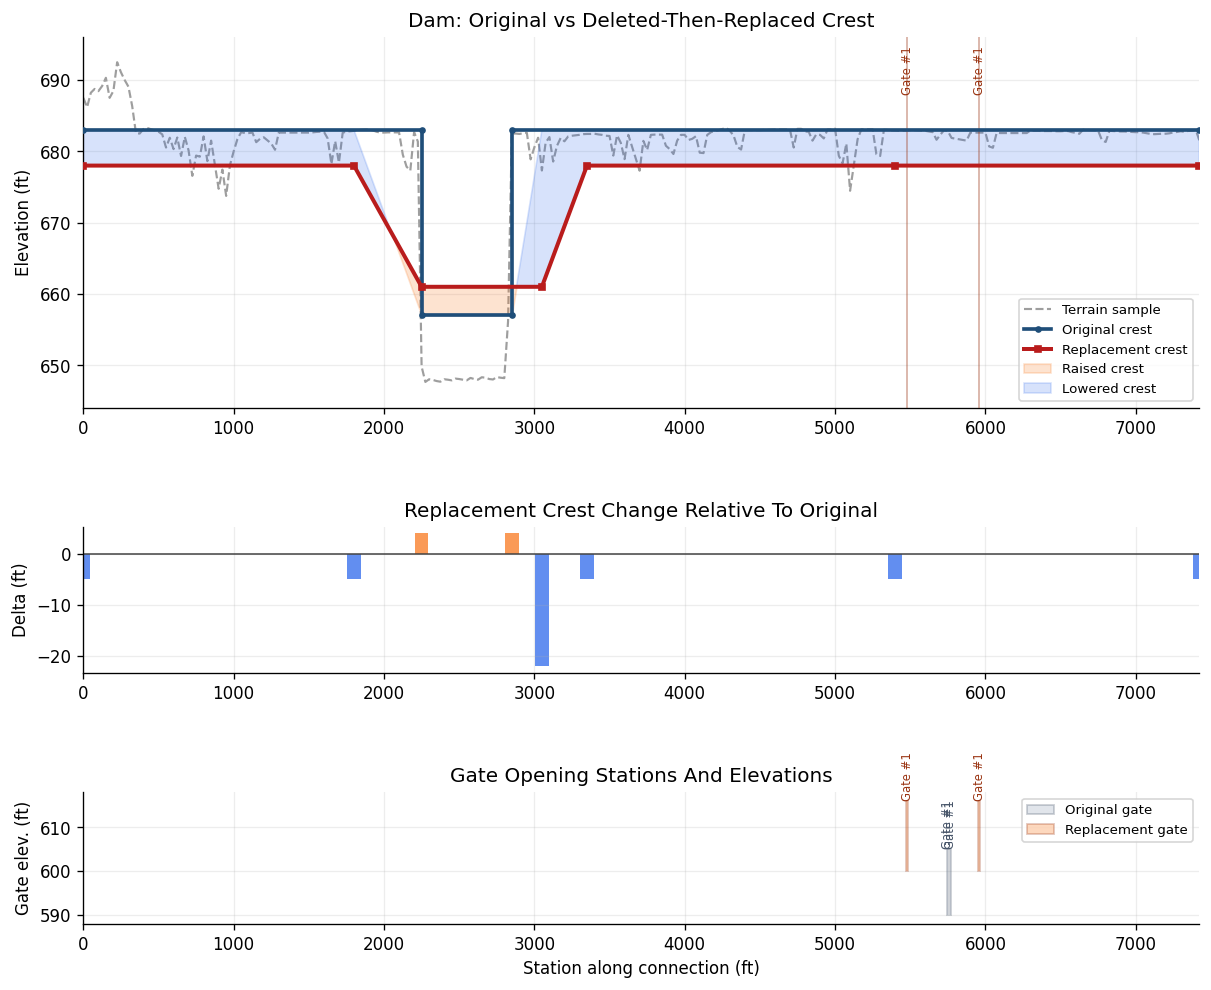

In [13]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9.6),
    sharex=False,
    gridspec_kw={"height_ratios": [3.8, 1.5, 1.35]},
)

ax = axes[0]
ax.plot(
    terrain_profile["Station"],
    terrain_profile["Elevation"],
    color="0.62",
    linewidth=1.3,
    linestyle="--",
    label="Terrain sample",
    zorder=1,
)
ax.plot(
    original_profile["Station"],
    original_profile["Elevation"],
    color="#1f4e79",
    linewidth=2.2,
    marker="o",
    markersize=3,
    label="Original crest",
    zorder=4,
)
ax.plot(
    updated_profile["Station"],
    updated_profile["Elevation"],
    color="#b91c1c",
    linewidth=2.4,
    marker="s",
    markersize=4,
    label="Replacement crest",
    zorder=5,
)
ax.fill_between(
    profile_comparison["Station"],
    profile_comparison["OriginalElevation"],
    profile_comparison["ModifiedElevation"],
    where=profile_comparison["Delta"] >= 0,
    color="#f97316",
    alpha=0.20,
    interpolate=True,
    label="Raised crest",
    zorder=2,
)
ax.fill_between(
    profile_comparison["Station"],
    profile_comparison["OriginalElevation"],
    profile_comparison["ModifiedElevation"],
    where=profile_comparison["Delta"] < 0,
    color="#2563eb",
    alpha=0.18,
    interpolate=True,
    label="Lowered crest",
    zorder=2,
)
add_gate_station_markers(ax, restored_gates)
ax.set_title(f"{TARGET_CONNECTION}: Original vs Deleted-Then-Replaced Crest")
ax.set_ylabel("Elevation (ft)")
set_profile_ylim(ax, [terrain_profile, original_profile, updated_profile])
dedupe_legend(ax, loc="lower right", fontsize=8)

ax_delta = axes[1]
colors = np.where(profile_comparison["Delta"] >= 0, "#f97316", "#2563eb")
ax_delta.bar(
    profile_comparison["Station"],
    profile_comparison["Delta"],
    width=90,
    color=colors,
    alpha=0.72,
    align="center",
)
ax_delta.axhline(0.0, color="0.25", linewidth=0.9)
ax_delta.set_title("Replacement Crest Change Relative To Original")
ax_delta.set_ylabel("Delta (ft)")

gate_ax = axes[2]
add_gate_rectangles(
    gate_ax,
    original_gates,
    facecolor="#94a3b8",
    edgecolor="#475569",
    label="Original gate",
)
add_gate_rectangles(
    gate_ax,
    restored_gates,
    facecolor="#f97316",
    edgecolor="#9a3412",
    label="Replacement gate",
)
gate_ax.set_ylabel("Gate elev. (ft)")
gate_ax.set_xlabel("Station along connection (ft)")
gate_ax.set_title("Gate Opening Stations And Elevations")
gate_ax.set_xlim(float(updated_profile["Station"].min()), float(updated_profile["Station"].max()))
set_profile_ylim(gate_ax, [], pd.concat([original_gates, restored_gates], ignore_index=True))
dedupe_legend(gate_ax, loc="upper right", fontsize=8)

for panel in axes:
    panel.set_xlim(float(updated_profile["Station"].min()), float(updated_profile["Station"].max()))

fig.subplots_adjust(hspace=0.55)
save_figure(fig, "214_connection_authoring_before_after_profile.png")
plt.show()


## Map View Of Modified Connection

Saved figure: G:\GH\ras-commander\working\connection_authoring\figures\214_connection_authoring_modified_connection_map.png


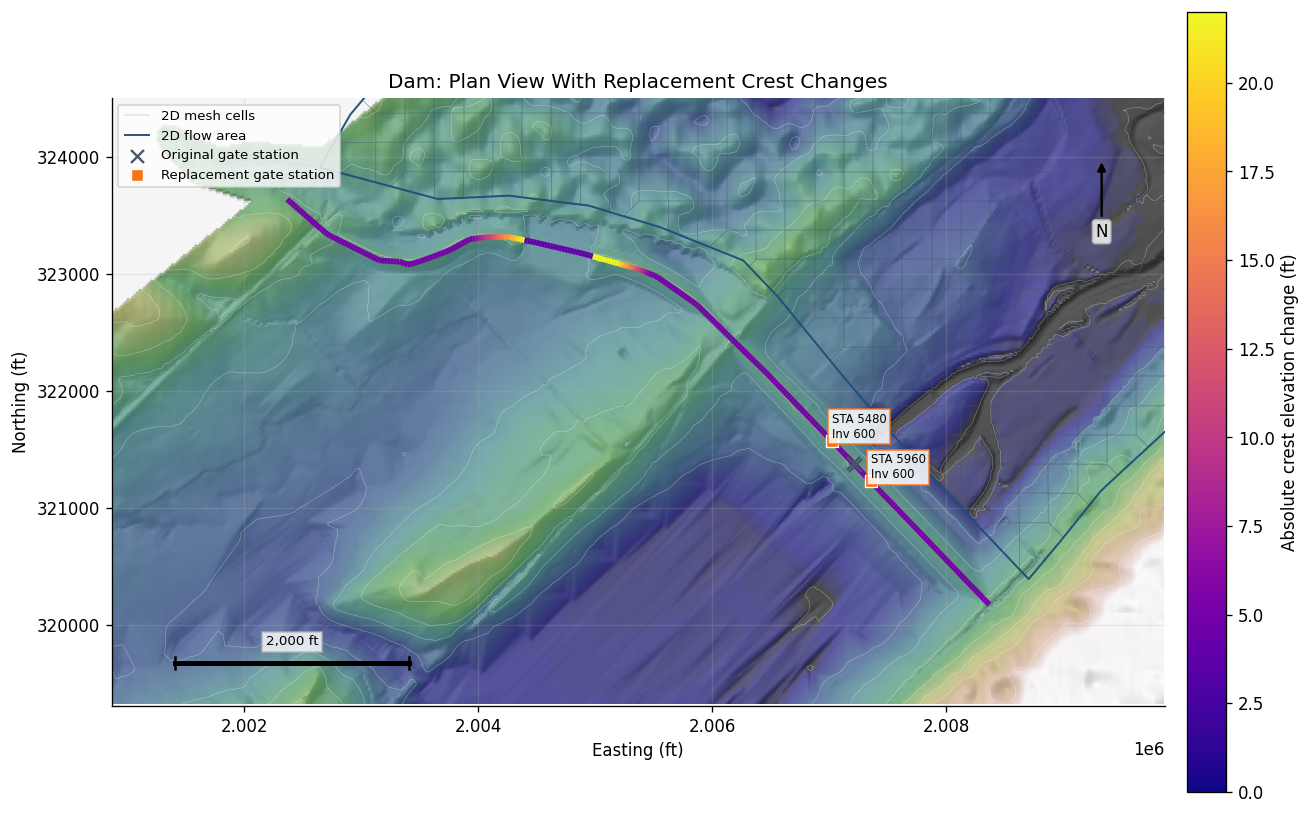

In [14]:
profile_diff_line = terrain_profile[["Station", "X", "Y"]].copy()
profile_diff_line["OriginalElevation"] = interpolated_elevations(
    original_profile,
    profile_diff_line["Station"],
)
profile_diff_line["ModifiedElevation"] = interpolated_elevations(
    updated_profile,
    profile_diff_line["Station"],
)
profile_diff_line["AbsDelta"] = (
    profile_diff_line["ModifiedElevation"] - profile_diff_line["OriginalElevation"]
).abs()

fig, ax = plt.subplots(figsize=(11, 7))
plot_context_map(
    ax,
    terrain_raster,
    mesh_areas,
    mesh_cells,
    bc_lines,
    connection_bounds,
    f"{TARGET_CONNECTION}: Plan View With Replacement Crest Changes",
    show_cells=True,
)

points = profile_diff_line[["X", "Y"]].to_numpy()
segments = np.stack([points[:-1], points[1:]], axis=1)
segment_delta = np.maximum(
    profile_diff_line["AbsDelta"].to_numpy()[:-1],
    profile_diff_line["AbsDelta"].to_numpy()[1:],
)
norm = Normalize(vmin=0.0, vmax=max(1.0, float(segment_delta.max())))
line_collection = LineCollection(
    segments,
    cmap="plasma",
    norm=norm,
    linewidth=3.4,
    zorder=12,
)
line_collection.set_array(segment_delta)
ax.add_collection(line_collection)

line = connection_line(original_coords)
for _, gate in original_gates.iterrows():
    for sta in gate["OpeningStations"]:
        pt = line.interpolate(float(sta))
        ax.scatter(pt.x, pt.y, marker="x", s=60, color="#475569", linewidth=1.4, zorder=14, label="Original gate station")

for _, gate in restored_gates.iterrows():
    for sta in gate["OpeningStations"]:
        pt = line.interpolate(float(sta))
        ax.scatter(pt.x, pt.y, marker="s", s=52, color="#f97316", edgecolor="white", linewidth=0.8, zorder=15, label="Replacement gate station")
        ax.text(
            pt.x,
            pt.y,
            f"STA {float(sta):.0f}\nInv {gate['InvertElevation']:.0f}",
            fontsize=7,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="#f97316", alpha=0.85, pad=2),
            zorder=16,
        )

cbar = fig.colorbar(line_collection, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Absolute crest elevation change (ft)")
dedupe_legend(ax, loc="upper left")
fig.tight_layout()
save_figure(fig, "214_connection_authoring_modified_connection_map.png")
plt.show()


## Summary

In [15]:
new_coords = GeomLateral.get_connection_line_coords(geom_file, TARGET_CONNECTION)
final_conns = GeomLateral.get_connections(geom_file)

summary = pd.DataFrame([{
    "Connection": TARGET_CONNECTION,
    "Deleted Proof": TARGET_CONNECTION not in after_delete["Name"].values,
    "Recreated Proof": TARGET_CONNECTION in after_recreate["Name"].values,
    "Original Weir Coef": 3.82,
    "Modified Weir Coef": REPLACEMENT_WEIR_COEF,
    "Original Weir Width": 100,
    "Modified Weir Width": REPLACEMENT_WEIR_WIDTH_FT,
    "Original Profile Points": len(original_profile),
    "Replacement Profile Points": len(updated_profile),
    "Max Crest Raise (ft)": profile_comparison["Delta"].max(),
    "Max Crest Lowering (ft)": profile_comparison["Delta"].min(),
    "Original Gate Stations": original_gates.iloc[0]["OpeningStations"],
    "Replacement Gate Stations": restored_gates.iloc[0]["OpeningStations"],
    "Original Gate Invert": original_gates.iloc[0]["InvertElevation"],
    "Replacement Gate Invert": restored_gates.iloc[0]["InvertElevation"],
    "Line Points Preserved": len(new_coords) == len(original_coords),
    "Connections Preserved": len(final_conns) == len(connections),
}])
display(summary)

assert len(final_conns) == len(connections)
assert len(new_coords) == len(original_coords)
assert len(restored_gates) == 1
assert summary.loc[0, "Deleted Proof"]
assert summary.loc[0, "Recreated Proof"]
print("Connection authoring workflow complete: deletion, recreation, profile, and gate changes verified.")


,Connection,Deleted Proof,Recreated Proof,Original Weir Coef,Modified Weir Coef,Original Weir Width,Modified Weir Width,Original Profile Points,Replacement Profile Points,Max Crest Raise (ft),Max Crest Lowering (ft),Original Gate Stations,Replacement Gate Stations,Original Gate Invert,Replacement Gate Invert,Line Points Preserved,Connections Preserved
0,Dam,True,True,3.82,2.25,100,180.0,6,7,4.0,-22.0,"[5745.0, 5765.0]","[5480.0, 5960.0]",590.0,600.0,True,True


Connection authoring workflow complete: deletion, recreation, profile, and gate changes verified.


## Compare HEC-RAS Results For Original, Deleted, And Replaced Connections

The file-level assertions above prove that the text geometry was deleted,
re-created, and round-tripped through `GeomLateral`. The hydraulic proof is
a three-scenario HEC-RAS comparison using Plan 04:

1. **Original connection** - unmodified `Dam` connection.
2. **No Dam connection** - `Dam` deleted from the geometry before compute.
3. **Deleted + replaced connection** - `Dam` deleted, re-created with the
   modified profile and gate layout, then computed.

The no-connection scenario is expected to have no `Dam` structure group in
the HDF. The plot below shows that result as a zero line because there is no
structure through which to report `Dam` total flow.


,Scenario,Compute Status,HDF,Project Folder
0,Original connection,reused complete HDF,BaldEagleDamBrk.p04.hdf,BaldEagleCrkMulti2D_214_original
1,No Dam connection,reused complete HDF,BaldEagleDamBrk.p04.hdf,BaldEagleCrkMulti2D_214_no_connection
2,Deleted + replaced connection,reused complete HDF,BaldEagleDamBrk.p04.hdf,BaldEagleCrkMulti2D_214_replaced


,Scenario,Dam Present In HDF,Connections In HDF,Time Steps,Peak Abs Total Flow (cfs),Peak Total Flow Time,Peak Abs Weir Flow (cfs),Max Headwater (ft),Max Tailwater (ft)
0,Original connection,True,"[BaldEagleCr Lower Levee, BaldEagleCr Middle Levee, BaldEagleCr Upper Levee, Dam]",865,96885.148438,1999-01-03 10:40:00,94281.679688,669.499756,598.579407
1,No Dam connection,False,"[BaldEagleCr Lower Levee, BaldEagleCr Middle Levee, BaldEagleCr Upper Levee]",865,0.000000,1999-01-01 12:00:00,0.000000,NaN,NaN
2,Deleted + replaced connection,True,"[BaldEagleCr Lower Levee, BaldEagleCr Middle Levee, BaldEagleCr Upper Levee, Dam]",865,96700.187500,1999-01-03 10:50:00,91969.312500,672.801208,598.646484


Saved figure: G:\GH\ras-commander\working\connection_authoring\figures\214_connection_authoring_total_flow_comparison.png


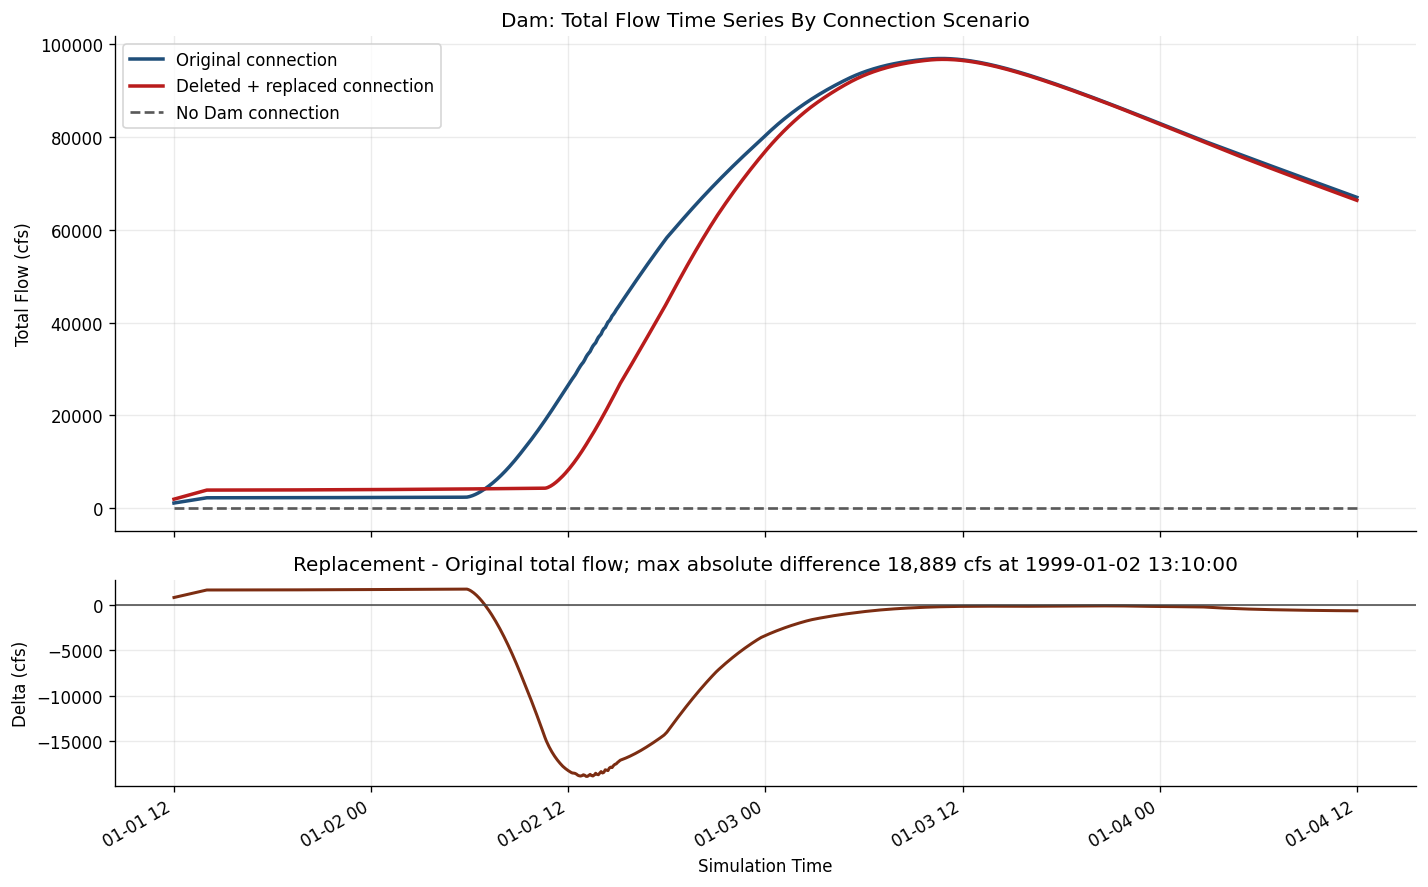

Scenario comparison complete. Max absolute replacement/original total-flow difference: 18,889 cfs.


In [16]:
import shutil
import re
from ras_commander import init_ras_project, RasCmdr
from ras_commander.hdf import HdfResultsPlan, HdfResultsBreach, HdfStruc

logging.getLogger("ras_commander").setLevel(logging.INFO)

SCENARIO_ROOT = WORK_ROOT / "compute_scenarios"
SCENARIO_ROOT.mkdir(parents=True, exist_ok=True)


def compute_errors(messages):
    lines = messages.splitlines() if messages else []
    return [
        line
        for line in lines
        if "ERROR" in line.upper()
        and "VOLUME ACCOUNTING" not in line.upper()
        and "ITERATIONS" not in line.upper()
        and "WSEL ERROR" not in line.upper()
    ]


def update_program_versions(project_path, ras_version):
    for filename in [
        f"BaldEagleDamBrk.p{SCENARIO_PLAN_NUMBER}",
        GEOM_FILE_NAME,
        "BaldEagleDamBrk.u01",
    ]:
        path = project_path / filename
        text = path.read_text(encoding="utf-8", errors="replace")
        text = re.sub(r"Program Version=.*", f"Program Version={ras_version}", text)
        path.write_text(text, encoding="utf-8")


def apply_no_connection(project_path):
    scenario_geom = project_path / GEOM_FILE_NAME
    before = GeomLateral.get_connections(scenario_geom)
    GeomLateral.delete_connection(scenario_geom, TARGET_CONNECTION, create_backup=False)
    after = GeomLateral.get_connections(scenario_geom)
    assert TARGET_CONNECTION not in after["Name"].values
    return {
        "Connections Before": len(before),
        "Connections After Delete": len(after),
        "Dam Present After Delete": False,
    }


def apply_deleted_then_replaced(project_path):
    scenario_geom = project_path / GEOM_FILE_NAME
    scenario_connections = GeomLateral.get_connections(scenario_geom)
    scenario_dam = scenario_connections.loc[
        scenario_connections["Name"] == TARGET_CONNECTION
    ].iloc[0]
    scenario_coords = GeomLateral.get_connection_line_coords(scenario_geom, TARGET_CONNECTION)

    GeomLateral.delete_connection(scenario_geom, TARGET_CONNECTION, create_backup=False)
    after_delete_scenario = GeomLateral.get_connections(scenario_geom)
    assert TARGET_CONNECTION not in after_delete_scenario["Name"].values

    GeomLateral.set_connection(
        scenario_geom,
        TARGET_CONNECTION,
        list(zip(scenario_coords["X"], scenario_coords["Y"])),
        upstream_area=scenario_dam["From"],
        downstream_area=scenario_dam["To"],
        routing_type=1,
        weir_width=REPLACEMENT_WEIR_WIDTH_FT,
        weir_coef=REPLACEMENT_WEIR_COEF,
        overflow_method_2d=True,
        create_backup=False,
    )
    GeomLateral.set_connection_profile(
        scenario_geom,
        TARGET_CONNECTION,
        replacement_profile,
        create_backup=False,
    )
    GeomLateral.set_connection_gates(
        scenario_geom,
        TARGET_CONNECTION,
        new_gates,
        create_backup=False,
    )

    after_replace_scenario = GeomLateral.get_connections(scenario_geom)
    profile = GeomLateral.get_connection_profile(scenario_geom, TARGET_CONNECTION)
    gates = GeomLateral.get_connection_gates(scenario_geom, TARGET_CONNECTION)

    assert TARGET_CONNECTION in after_replace_scenario["Name"].values
    assert np.allclose(profile["Elevation"], replacement_profile["Elevation"], atol=0.001)
    assert [float(s) for s in gates.iloc[0]["OpeningStations"]] == REPLACEMENT_GATE_STATIONS_FT
    return {
        "Connections Before": len(scenario_connections),
        "Connections After Delete": len(after_delete_scenario),
        "Connections After Replace": len(after_replace_scenario),
        "Profile Points": len(profile),
        "Gate Stations": gates.iloc[0]["OpeningStations"],
        "Gate Invert": float(gates.iloc[0]["InvertElevation"]),
    }


def scenario_folder(suffix):
    return SCENARIO_ROOT / f"{PROJECT_NAME}_{suffix}"


def hdf_is_complete(hdf_path):
    if not hdf_path.exists():
        return False
    messages = HdfResultsPlan.get_compute_messages(hdf_path)
    return "Complete Process" in messages and not compute_errors(messages)


def scenario_geometry_is_ready(project_path, scenario_key):
    scenario_geom = project_path / GEOM_FILE_NAME
    if not scenario_geom.exists():
        return False
    try:
        scenario_connections = GeomLateral.get_connections(scenario_geom)
        dam_present = TARGET_CONNECTION in scenario_connections["Name"].values
        if scenario_key == "original":
            return dam_present
        if scenario_key == "deleted":
            return not dam_present
        if scenario_key == "replaced":
            if not dam_present:
                return False
            profile = GeomLateral.get_connection_profile(scenario_geom, TARGET_CONNECTION)
            gates = GeomLateral.get_connection_gates(scenario_geom, TARGET_CONNECTION)
            return (
                len(profile) == len(replacement_profile)
                and np.allclose(profile["Elevation"], replacement_profile["Elevation"], atol=0.001)
                and [float(s) for s in gates.iloc[0]["OpeningStations"]] == REPLACEMENT_GATE_STATIONS_FT
                and np.isclose(float(gates.iloc[0]["InvertElevation"]), REPLACEMENT_GATE_INVERT_FT)
            )
    except Exception:
        return False
    return False


def prepare_and_compute_scenario(label, scenario_key, suffix, modifier=None):
    project_path = scenario_folder(suffix)
    hdf_path = project_path / f"BaldEagleDamBrk.p{SCENARIO_PLAN_NUMBER}.hdf"

    if hdf_is_complete(hdf_path) and scenario_geometry_is_ready(project_path, scenario_key):
        return {
            "Scenario": label,
            "Scenario Key": scenario_key,
            "Project Path": project_path,
            "HDF Path": hdf_path,
            "Compute Status": "reused complete HDF",
            "Edit Summary": {},
        }

    if project_path.exists():
        shutil.rmtree(project_path)

    project_path = RasExamples.extract_project(PROJECT_NAME, output_path=SCENARIO_ROOT, suffix=suffix)
    ras_scenario = init_ras_project(project_path, "7.0")
    update_program_versions(project_path, ras_scenario.ras_version)
    edit_summary = modifier(project_path) if modifier else {}

    result = RasCmdr.compute_plan(
        SCENARIO_PLAN_NUMBER,
        ras_object=ras_scenario,
        force_geompre=True,
        force_rerun=True,
        num_cores=4,
        verify=False,
        timeout_sec=900,
    )
    assert result, f"HEC-RAS compute failed for {label}"
    assert hdf_path.exists(), f"Missing HDF after compute: {hdf_path}"

    messages = HdfResultsPlan.get_compute_messages(hdf_path)
    errors = compute_errors(messages)
    assert not errors, f"HEC-RAS reported errors for {label}: {errors[:5]}"

    return {
        "Scenario": label,
        "Scenario Key": scenario_key,
        "Project Path": project_path,
        "HDF Path": hdf_path,
        "Compute Status": "computed",
        "Edit Summary": edit_summary,
    }


scenario_specs = [
    ("Original connection", "original", "214_original", None),
    ("No Dam connection", "deleted", "214_no_connection", apply_no_connection),
    ("Deleted + replaced connection", "replaced", "214_replaced", apply_deleted_then_replaced),
]

scenario_results = [
    prepare_and_compute_scenario(label, key, suffix, modifier)
    for label, key, suffix, modifier in scenario_specs
]

scenario_audit = pd.DataFrame([
    {
        "Scenario": item["Scenario"],
        "Compute Status": item["Compute Status"],
        "HDF": item["HDF Path"].name,
        "Project Folder": item["Project Path"].name,
        **item["Edit Summary"],
    }
    for item in scenario_results
])
display(scenario_audit)

flow_frames = []
flow_summary_rows = []
reference_datetimes = None

for item in scenario_results:
    hdf_path = item["HDF Path"]
    connections_in_hdf = HdfStruc.list_sa2d_connections(hdf_path)
    dam_in_hdf = TARGET_CONNECTION in connections_in_hdf

    if dam_in_hdf:
        ts = HdfResultsBreach.get_structure_variables(hdf_path, TARGET_CONNECTION).copy()
        if reference_datetimes is None:
            reference_datetimes = ts["datetime"].copy()
    else:
        assert reference_datetimes is not None, "Original scenario must be processed before no-connection scenario"
        ts = pd.DataFrame({
            "datetime": reference_datetimes,
            "total_flow": 0.0,
            "weir_flow": 0.0,
            "hw": np.nan,
            "tw": np.nan,
        })

    ts["Scenario"] = item["Scenario"]
    ts["Dam Present In HDF"] = dam_in_hdf
    flow_frames.append(ts)

    peak_idx = ts["total_flow"].abs().idxmax()
    flow_summary_rows.append({
        "Scenario": item["Scenario"],
        "Dam Present In HDF": dam_in_hdf,
        "Connections In HDF": connections_in_hdf,
        "Time Steps": len(ts),
        "Peak Abs Total Flow (cfs)": ts["total_flow"].abs().max(),
        "Peak Total Flow Time": ts.loc[peak_idx, "datetime"],
        "Peak Abs Weir Flow (cfs)": ts["weir_flow"].abs().max(),
        "Max Headwater (ft)": ts["hw"].max(),
        "Max Tailwater (ft)": ts["tw"].max(),
    })

flow_comparison = pd.concat(flow_frames, ignore_index=True)
flow_summary = pd.DataFrame(flow_summary_rows)
display(flow_summary)

original_ts = flow_comparison[flow_comparison["Scenario"] == "Original connection"]
replaced_ts = flow_comparison[flow_comparison["Scenario"] == "Deleted + replaced connection"]
total_flow_delta = original_ts[["datetime", "total_flow"]].merge(
    replaced_ts[["datetime", "total_flow"]],
    on="datetime",
    suffixes=("_original", "_replaced"),
)
total_flow_delta["Replacement Minus Original (cfs)"] = (
    total_flow_delta["total_flow_replaced"] - total_flow_delta["total_flow_original"]
)

max_abs_total_flow_difference = total_flow_delta["Replacement Minus Original (cfs)"].abs().max()
peak_delta_time = total_flow_delta.loc[
    total_flow_delta["Replacement Minus Original (cfs)"].abs().idxmax(),
    "datetime",
]

fig, (ax, ax_delta) = plt.subplots(
    2,
    1,
    figsize=(12, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.25]},
)
line_styles = {
    "Original connection": {"color": "#1f4e79", "linewidth": 2.1, "linestyle": "-"},
    "Deleted + replaced connection": {"color": "#b91c1c", "linewidth": 2.1, "linestyle": "-"},
    "No Dam connection": {"color": "0.35", "linewidth": 1.6, "linestyle": "--"},
}
for scenario_name, style in line_styles.items():
    scenario_ts = flow_comparison[flow_comparison["Scenario"] == scenario_name]
    ax.plot(
        scenario_ts["datetime"],
        scenario_ts["total_flow"],
        label=scenario_name,
        **style,
    )
ax.set_title(f"{TARGET_CONNECTION}: Total Flow Time Series By Connection Scenario")
ax.set_ylabel("Total Flow (cfs)")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")

ax_delta.plot(
    total_flow_delta["datetime"],
    total_flow_delta["Replacement Minus Original (cfs)"],
    color="#7c2d12",
    linewidth=1.8,
)
ax_delta.axhline(0.0, color="0.25", linewidth=0.9)
ax_delta.set_title(
    f"Replacement - Original total flow; max absolute difference "
    f"{max_abs_total_flow_difference:,.0f} cfs at {peak_delta_time}"
)
ax_delta.set_ylabel("Delta (cfs)")
ax_delta.set_xlabel("Simulation Time")
ax_delta.grid(True, alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
save_figure(fig, "214_connection_authoring_total_flow_comparison.png")
plt.show()

assert flow_summary.loc[
    flow_summary["Scenario"] == "Original connection",
    "Dam Present In HDF",
].iloc[0]
assert not flow_summary.loc[
    flow_summary["Scenario"] == "No Dam connection",
    "Dam Present In HDF",
].iloc[0]
assert flow_summary.loc[
    flow_summary["Scenario"] == "Deleted + replaced connection",
    "Dam Present In HDF",
].iloc[0]
assert max_abs_total_flow_difference > 1000.0

print(f"Scenario comparison complete. Max absolute replacement/original total-flow difference: {max_abs_total_flow_difference:,.0f} cfs.")


## Inspect Extracted Scenario Time Series

The HDF comparison above proves three separate outcomes:

- the original `Dam` connection produces a `Dam` total-flow time series
- the deleted/no-connection result has no `Dam` structure in the HDF
- the deleted-then-replaced `Dam` connection computes and produces a different `Dam` total-flow time series


In [17]:
for scenario_name in [
    "Original connection",
    "Deleted + replaced connection",
    "No Dam connection",
]:
    scenario_ts = flow_comparison[flow_comparison["Scenario"] == scenario_name]
    print(f"\n{scenario_name}: first 5 time steps")
    display(scenario_ts[["datetime", "total_flow", "weir_flow", "hw", "tw", "Dam Present In HDF"]].head())
    print(f"{scenario_name}: last 5 time steps")
    display(scenario_ts[["datetime", "total_flow", "weir_flow", "hw", "tw", "Dam Present In HDF"]].tail())

no_connection_peak = flow_summary.loc[
    flow_summary["Scenario"] == "No Dam connection",
    "Peak Abs Total Flow (cfs)",
].iloc[0]
replaced_peak = flow_summary.loc[
    flow_summary["Scenario"] == "Deleted + replaced connection",
    "Peak Abs Total Flow (cfs)",
].iloc[0]

assert no_connection_peak == 0.0
assert replaced_peak > 0.0

print(f"\n{'='*70}")
print("STRUCTURE RESULT VALIDATION")
print(f"{'='*70}")
print("  Original:                Dam present with total-flow time series")
print("  No Dam connection:       Dam absent from HDF; plotted as zero structure flow")
print("  Deleted + replaced:      Dam present with modified total-flow time series")
print(f"  Max flow difference:     {max_abs_total_flow_difference:,.0f} cfs")
print(f"{'='*70}")



Original connection: first 5 time steps


,datetime,total_flow,weir_flow,hw,tw,Dam Present In HDF
0,1999-01-01 12:00:00,1130.885986,0.0,650.001099,586.846252,True
1,1999-01-01 12:05:00,1178.005005,0.0,650.000977,586.988403,True
2,1999-01-01 12:10:00,1225.125977,0.0,650.001038,587.074036,True
3,1999-01-01 12:15:00,1272.250000,0.0,650.001404,587.155518,True
4,1999-01-01 12:20:00,1319.377808,0.0,650.002075,587.235779,True


Original connection: last 5 time steps


,datetime,total_flow,weir_flow,hw,tw,Dam Present In HDF
860,1999-01-04 11:40:00,67404.289062,64843.703125,666.902344,596.484436,True
861,1999-01-04 11:45:00,67296.960938,64736.550781,666.892090,596.475769,True
862,1999-01-04 11:50:00,67189.703125,64629.457031,666.881836,596.467041,True
863,1999-01-04 11:55:00,67082.515625,64522.445312,666.871582,596.458252,True
864,1999-01-04 12:00:00,66974.757812,64414.859375,666.861267,596.449524,True



Deleted + replaced connection: first 5 time steps


...


No Dam connection: first 5 time steps


,datetime,total_flow,weir_flow,hw,tw,Dam Present In HDF
865,1999-01-01 12:00:00,0.0,0.0,NaN,NaN,False
866,1999-01-01 12:05:00,0.0,0.0,NaN,NaN,False
867,1999-01-01 12:10:00,0.0,0.0,NaN,NaN,False
868,1999-01-01 12:15:00,0.0,0.0,NaN,NaN,False
869,1999-01-01 12:20:00,0.0,0.0,NaN,NaN,False


No Dam connection: last 5 time steps


,datetime,total_flow,weir_flow,hw,tw,Dam Present In HDF
1725,1999-01-04 11:40:00,0.0,0.0,NaN,NaN,False
1726,1999-01-04 11:45:00,0.0,0.0,NaN,NaN,False
1727,1999-01-04 11:50:00,0.0,0.0,NaN,NaN,False
1728,1999-01-04 11:55:00,0.0,0.0,NaN,NaN,False
1729,1999-01-04 12:00:00,0.0,0.0,NaN,NaN,False



STRUCTURE RESULT VALIDATION
  Original:                Dam present with total-flow time series
  No Dam connection:       Dam absent from HDF; plotted as zero structure flow
  Deleted + replaced:      Dam present with modified total-flow time series
  Max flow difference:     18,889 cfs
